# Plant Disease Data Processing

This notebook is a clean, end-to-end preprocessing pipeline that can be executed from Cell 1 to the final cell without manual edits.

Pipeline:
1. Audit raw dataset in data/train and data/val.
2. Merge plant+disease labels into disease-only labels.
3. Build cleaned dataset in plant_data_clean and fix missing validation classes.
4. Analyze class and image-size distributions.
5. Resize images to 224x224 with aspect-ratio-preserving padding in Resized_Data.
6. Deduplicate and create train/val/test in train_ready_data.
7. Run leakage checks and export a preprocessing report.

In [1]:
import os
import re
import json
import shutil
import random
import hashlib
import importlib
import subprocess
import sys
from pathlib import Path
from collections import defaultdict, Counter

def ensure_package(package_name, module_name=None):
    try:
        importlib.import_module(module_name or package_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

ensure_package('numpy')
ensure_package('matplotlib')
ensure_package('seaborn')
ensure_package('pillow', 'PIL')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

RAW_ROOT = Path('data')
RAW_TRAIN = RAW_ROOT / 'train'
RAW_VAL = RAW_ROOT / 'val'

CLEAN_ROOT = Path('plant_data_clean')
RESIZED_ROOT = Path('Resized_Data')
READY_ROOT = Path('train_ready_data')

TARGET_SIZE = 224
MIN_VAL_SAMPLES_PER_CLASS = 10
REBUILD_OUTPUTS = True
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert RAW_TRAIN.exists() and RAW_VAL.exists(), 'Expected folders: data/train and data/val'

print('Configuration loaded')
print(f'Raw train: {RAW_TRAIN.resolve()}')
print(f'Raw val: {RAW_VAL.resolve()}')
print(f'Output clean: {CLEAN_ROOT}')
print(f'Output resized: {RESIZED_ROOT}')
print(f'Output ready: {READY_ROOT}')

Configuration loaded
Raw train: C:\Users\Sevak\Desktop\New folder\data\train
Raw val: C:\Users\Sevak\Desktop\New folder\data\val
Output clean: plant_data_clean
Output resized: Resized_Data
Output ready: train_ready_data


In [2]:
def is_image_file(path):
    return path.is_file() and path.suffix.lower() in IMAGE_EXTS

def slugify(text):
    text = text.strip().lower().replace('___', ' ')
    text = re.sub(r'[^a-z0-9]+', '_', text)
    return re.sub(r'_+', '_', text).strip('_')

def extract_disease_label(folder_name):
    if '___' in folder_name:
        return slugify(folder_name.split('___', 1)[1])

    parts = folder_name.replace('_', ' ').split()
    disease = ' '.join(parts[1:]) if len(parts) > 1 else parts[0]
    return slugify(disease)

def reset_dir(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def count_images_in_class_dir(class_dir):
    return sum(1 for p in class_dir.iterdir() if is_image_file(p))

def get_split_counts(split_dir):
    counts = {}
    if not split_dir.exists():
        return counts

    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            n = count_images_in_class_dir(class_dir)
            if n > 0:
                counts[class_dir.name] = n
    return counts

def summarize_split(split_dir, split_name):
    counts = get_split_counts(split_dir)
    total = sum(counts.values())

    print('')
    print(f'[{split_name}]')
    print(f'Classes: {len(counts)} | Images: {total}')

    if counts:
        print('Top classes:')
        top = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]
        for cls, n in top:
            print(f'  {cls}: {n}')

    return counts

def copy_unique(src_path, dst_dir, prefix=''):
    dst_dir.mkdir(parents=True, exist_ok=True)
    suffix = src_path.suffix.lower()
    candidate = dst_dir / f'{prefix}{src_path.stem}{suffix}'
    idx = 1
    while candidate.exists():
        candidate = dst_dir / f'{prefix}{src_path.stem}_{idx}{suffix}'
        idx += 1
    shutil.copy2(src_path, candidate)
    return candidate

def file_md5(path):
    hasher = hashlib.md5()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            hasher.update(chunk)
    return hasher.hexdigest()

def resize_with_padding(src_path, dst_path, target_size=224):
    with Image.open(src_path) as img:
        img = img.convert('RGB')
        w, h = img.size
        scale = target_size / max(w, h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))

        resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        canvas = Image.new('RGB', (target_size, target_size), (0, 0, 0))
        x = (target_size - new_w) // 2
        y = (target_size - new_h) // 2
        canvas.paste(resized, (x, y))

        dst_path.parent.mkdir(parents=True, exist_ok=True)
        canvas.save(dst_path, format='JPEG', quality=95)

def plot_split_distribution(counts, title, figsize=(16, 6)):
    if not counts:
        print(f'No data to plot for: {title}')
        return

    ordered = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))
    plt.figure(figsize=figsize)
    plt.bar(list(ordered.keys()), list(ordered.values()))
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel('Classes')
    plt.ylabel('Number of images')
    plt.tight_layout()
    plt.show()

def sample_images_grid(split_dir, n=8, seed=42):
    rng = random.Random(seed)
    classes = [d for d in split_dir.iterdir() if d.is_dir()]

    if not classes:
        print(f'No classes found in {split_dir}')
        return

    selected = []
    for _ in range(n):
        cls_dir = rng.choice(classes)
        images = [p for p in cls_dir.iterdir() if is_image_file(p)]
        if images:
            selected.append((cls_dir.name, rng.choice(images)))

    if not selected:
        print(f'No images found in {split_dir}')
        return

    cols = 4
    rows = int(np.ceil(len(selected) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (label, img_path) in enumerate(selected, start=1):
        with Image.open(img_path) as img:
            plt.subplot(rows, cols, i)
            plt.imshow(img)
            plt.title(label)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

def split_counts_for_class(n, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    if n <= 0:
        return 0, 0, 0
    if n == 1:
        return 1, 0, 0
    if n == 2:
        return 1, 1, 0

    train_n = max(1, int(round(n * train_ratio)))
    val_n = max(1, int(round(n * val_ratio)))
    test_n = max(1, n - train_n - val_n)

    while train_n + val_n + test_n > n:
        largest = max([('train', train_n), ('val', val_n), ('test', test_n)], key=lambda x: x[1])[0]
        if largest == 'train' and train_n > 1:
            train_n -= 1
        elif largest == 'val' and val_n > 1:
            val_n -= 1
        elif largest == 'test' and test_n > 1:
            test_n -= 1
        else:
            break

    while train_n + val_n + test_n < n:
        train_n += 1

    return train_n, val_n, test_n

print('Helper functions ready')

Helper functions ready


## Step 1 - Raw Dataset Audit

Inspect original train and validation folders and check class consistency before transformation.

In [3]:
def summarize_raw_split(split_dir, split_name):
    original_counts = {}
    disease_counts = defaultdict(int)

    for folder in sorted(split_dir.iterdir()):
        if not folder.is_dir():
            continue

        n = count_images_in_class_dir(folder)
        if n == 0:
            continue

        original_counts[folder.name] = n
        disease_counts[extract_disease_label(folder.name)] += n

    print('')
    print(f'[{split_name}]')
    print(f'Original classes: {len(original_counts)}')
    print(f'Disease-only labels after merge: {len(disease_counts)}')
    print(f'Total images: {sum(original_counts.values())}')

    return original_counts, disease_counts

train_original_counts, train_disease_counts = summarize_raw_split(RAW_TRAIN, 'RAW TRAIN')
val_original_counts, val_disease_counts = summarize_raw_split(RAW_VAL, 'RAW VAL')

missing_in_val = sorted(set(train_disease_counts) - set(val_disease_counts))
print('')
print(f'Disease labels missing in raw val: {len(missing_in_val)}')
if missing_in_val:
    print(missing_in_val)


[RAW TRAIN]
Original classes: 82
Disease-only labels after merge: 40
Total images: 7783

[RAW VAL]
Original classes: 71
Disease-only labels after merge: 39
Total images: 390

Disease labels missing in raw val: 1
['pepper_powdery_mildew']


## Step 2 - Build Clean Disease-Only Dataset

Create plant_data_clean/train and plant_data_clean/val, then ensure every training class exists in validation with at least a small number of samples.

In [4]:
if REBUILD_OUTPUTS:
    for out_dir in [CLEAN_ROOT, RESIZED_ROOT, READY_ROOT]:
        if out_dir.exists():
            shutil.rmtree(out_dir)
            print(f'Removed previous output: {out_dir}')

def build_clean_split(src_split, dst_split, split_name):
    dst_split.mkdir(parents=True, exist_ok=True)
    copied = 0

    for src_class in sorted(src_split.iterdir()):
        if not src_class.is_dir():
            continue

        disease_label = extract_disease_label(src_class.name)
        dst_class = dst_split / disease_label
        class_prefix = f'{slugify(src_class.name)}__'

        for img_path in sorted(src_class.iterdir()):
            if not is_image_file(img_path):
                continue
            copy_unique(img_path, dst_class, prefix=class_prefix)
            copied += 1

    print(f'{split_name}: copied {copied} images')

def ensure_val_class_coverage(train_split, val_split, min_val_samples=10, seed=42):
    rng = random.Random(seed)
    train_counts = get_split_counts(train_split)
    val_counts = get_split_counts(val_split)
    moved = {}

    for cls in sorted(train_counts):
        val_n = val_counts.get(cls, 0)
        needed = max(0, min_val_samples - val_n)
        if needed == 0:
            continue

        src_dir = train_split / cls
        dst_dir = val_split / cls
        dst_dir.mkdir(parents=True, exist_ok=True)

        candidates = [p for p in src_dir.iterdir() if is_image_file(p)]
        movable = max(0, len(candidates) - 1)
        move_n = min(needed, movable)

        if move_n <= 0:
            continue

        for img_path in rng.sample(candidates, move_n):
            target = dst_dir / img_path.name
            idx = 1
            while target.exists():
                target = dst_dir / f'{img_path.stem}_{idx}{img_path.suffix.lower()}'
                idx += 1
            shutil.move(str(img_path), str(target))

        moved[cls] = move_n

    return moved

build_clean_split(RAW_TRAIN, CLEAN_ROOT / 'train', 'Clean train')
build_clean_split(RAW_VAL, CLEAN_ROOT / 'val', 'Clean val')

moved_log = ensure_val_class_coverage(
    CLEAN_ROOT / 'train',
    CLEAN_ROOT / 'val',
    min_val_samples=MIN_VAL_SAMPLES_PER_CLASS,
    seed=SEED
)

print('')
if moved_log:
    print('Moved images from clean train to clean val:')
    for cls, moved_n in moved_log.items():
        print(f'  {cls}: {moved_n}')
else:
    print('No balancing move needed')

clean_train_counts = summarize_split(CLEAN_ROOT / 'train', 'CLEAN TRAIN')
clean_val_counts = summarize_split(CLEAN_ROOT / 'val', 'CLEAN VAL')

still_missing = sorted(set(clean_train_counts) - set(clean_val_counts))
print('')
print(f'Missing classes in clean val after balancing: {len(still_missing)}')
if still_missing:
    print(still_missing)

Clean train: copied 7783 images
Clean val: copied 390 images

Moved images from clean train to clean val:
  pepper_powdery_mildew: 10

[CLEAN TRAIN]
Classes: 40 | Images: 7773
Top classes:
  powdery_mildew: 840
  rust: 681
  downy_mildew: 679
  canker: 330
  stripe_rust: 298
  early_blight: 289
  black_rot: 283
  scab: 276
  head_scab: 259
  leaf_rust: 231

[CLEAN VAL]
Classes: 40 | Images: 400
Top classes:
  alternaria_leaf_spot: 10
  angular_leaf_spot: 10
  anthracnose: 10
  bacterial_leaf_spot: 10
  bacterial_leaf_streak_black_chaff: 10
  bacterial_wilt: 10
  berry_blotch: 10
  black_leaf_streak: 10
  black_rot: 10
  brown_rot: 10

Missing classes in clean val after balancing: 0


## Results after manual cleaning

In [6]:
def count_images(folder):
    total = 0
    
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                total += 1
                
    return total


train_path = r"plant_data_clean\train"
val_path = r"plant_data_clean\val"

train_count = count_images(train_path)
val_count = count_images(val_path)

print(f"Train images: {train_count}")
print(f"Validation images: {val_count}")
print(f"Total images: {train_count + val_count}")

Train images: 8366
Validation images: 428
Total images: 8794


## Step 3 - Quick EDA on Clean Dataset

Plot class distributions and display sample images for quick visual sanity-checking.

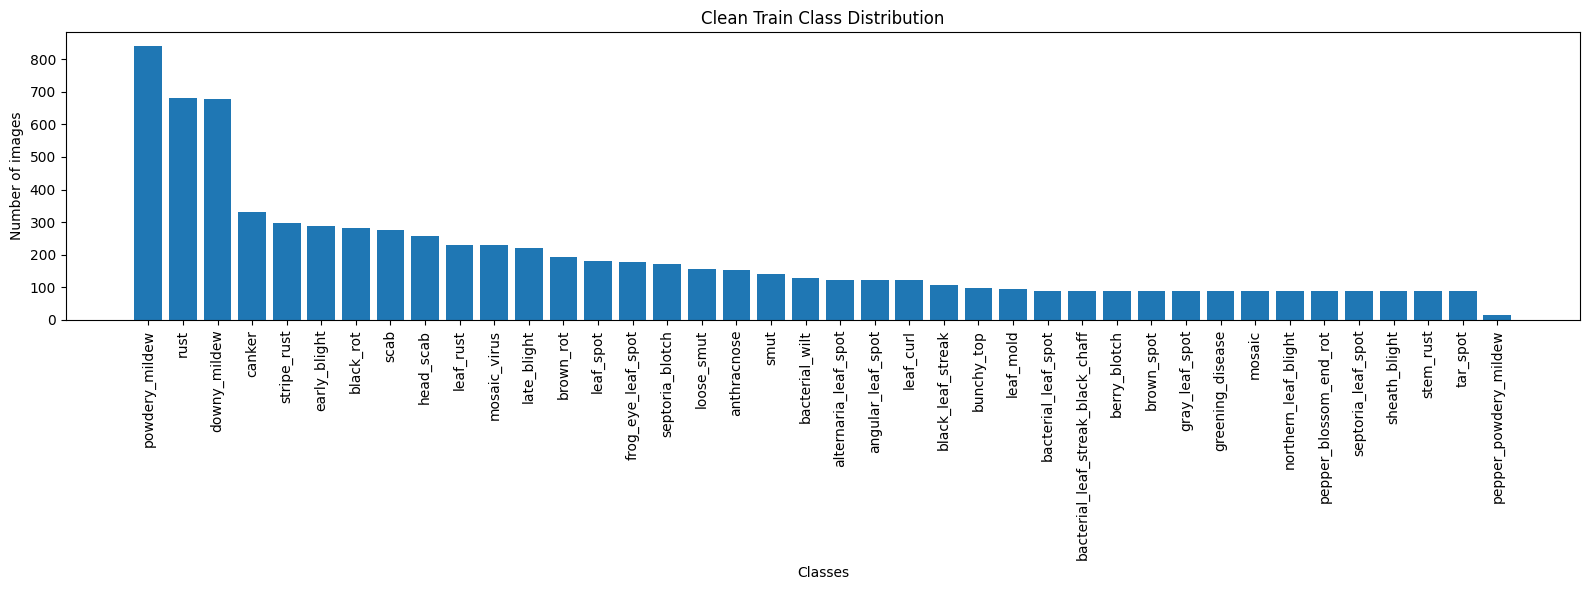

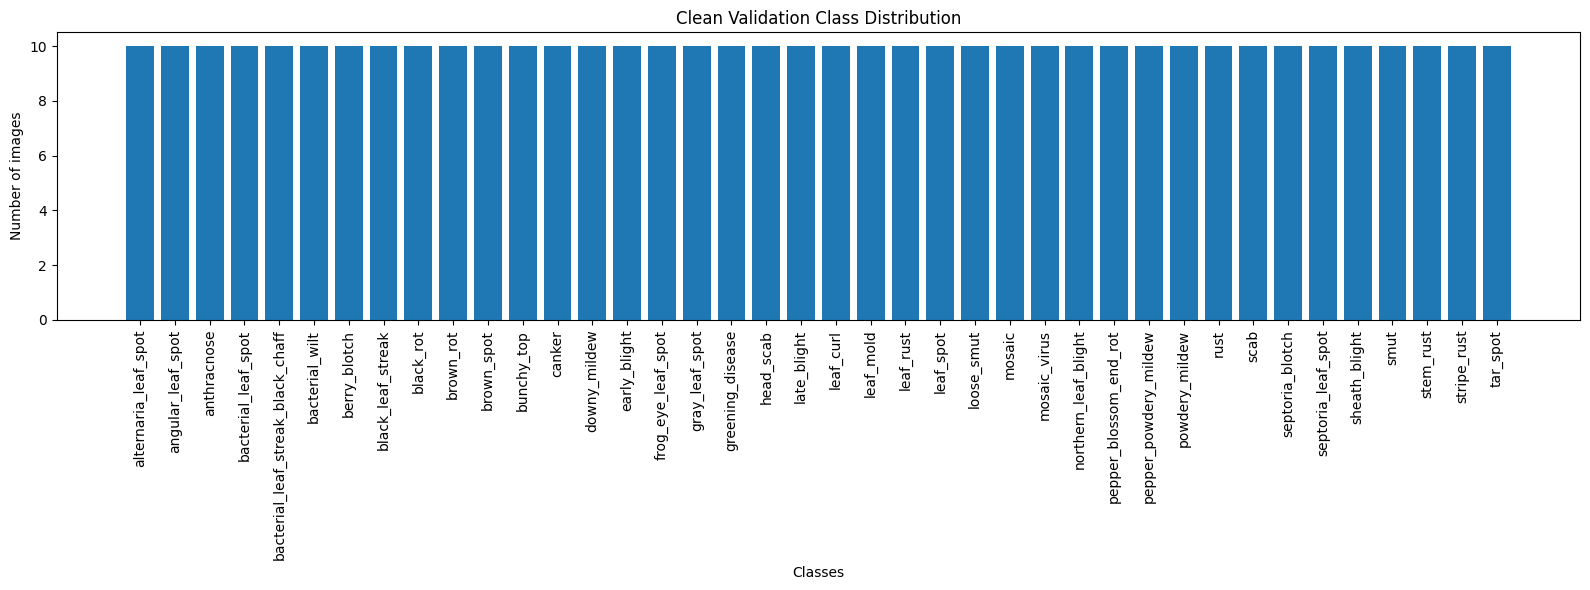

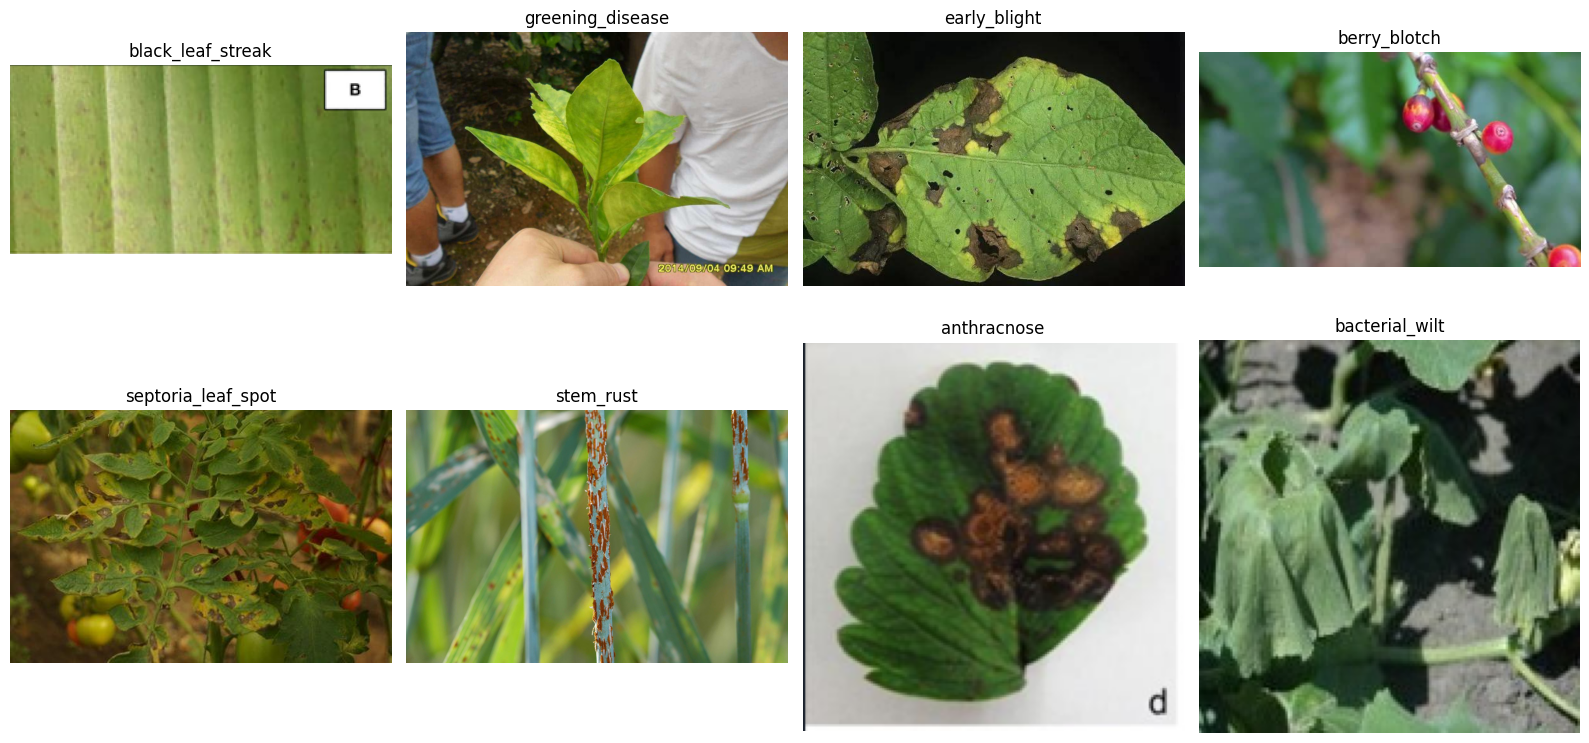

In [7]:
plot_split_distribution(clean_train_counts, 'Clean Train Class Distribution')
plot_split_distribution(clean_val_counts, 'Clean Validation Class Distribution')
sample_images_grid(CLEAN_ROOT / 'train', n=8, seed=SEED)

## Step 4 - Image Size Analysis

Analyze original image dimensions after label cleaning to confirm variability and justify resizing.

Images scanned for size stats: 8794
Median width: 640.0
Median height: 501.0


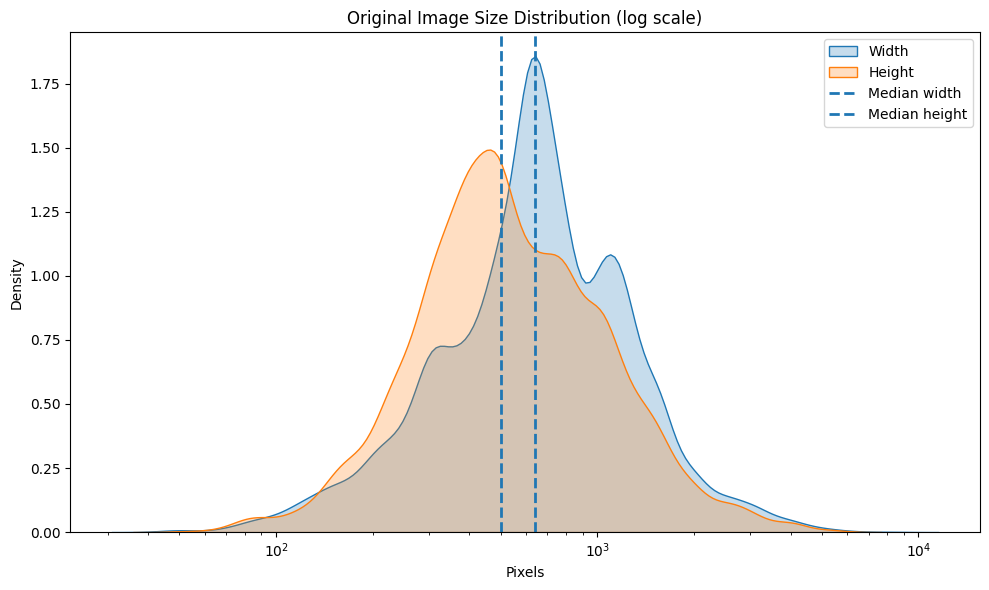

In [8]:
def collect_image_sizes(root_dir):
    widths = []
    heights = []

    for p in root_dir.rglob('*'):
        if not is_image_file(p):
            continue
        try:
            with Image.open(p) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception as exc:
            print(f'Warning - failed to read {p}: {exc}')

    return widths, heights

widths, heights = collect_image_sizes(CLEAN_ROOT)
print(f'Images scanned for size stats: {len(widths)}')

if widths:
    print(f'Median width: {np.median(widths):.1f}')
    print(f'Median height: {np.median(heights):.1f}')

    plt.figure(figsize=(10, 6))
    sns.kdeplot(widths, fill=True, label='Width', log_scale=True)
    sns.kdeplot(heights, fill=True, label='Height', log_scale=True)
    plt.axvline(np.median(widths), linestyle='--', linewidth=2, label='Median width')
    plt.axvline(np.median(heights), linestyle='--', linewidth=2, label='Median height')
    plt.title('Original Image Size Distribution (log scale)')
    plt.xlabel('Pixels')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No images found for size analysis')

## Step 5 - Resize to 224x224

Resize all clean images with aspect-ratio-preserving padding into Resized_Data.

In [9]:
def build_resized_dataset(clean_root, resized_root, target_size=224):
    processed = 0

    for split in ['train', 'val']:
        src_split = clean_root / split
        dst_split = resized_root / split

        if not src_split.exists():
            continue

        for class_dir in sorted(src_split.iterdir()):
            if not class_dir.is_dir():
                continue

            for img_path in sorted(class_dir.iterdir()):
                if not is_image_file(img_path):
                    continue

                dst_dir = dst_split / class_dir.name
                dst_path = dst_dir / f'{img_path.stem}.jpg'
                idx = 1
                while dst_path.exists():
                    dst_path = dst_dir / f'{img_path.stem}_{idx}.jpg'
                    idx += 1

                try:
                    resize_with_padding(img_path, dst_path, target_size=target_size)
                    processed += 1
                except Exception as exc:
                    print(f'Warning - resize failed for {img_path}: {exc}')

    return processed

processed_n = build_resized_dataset(CLEAN_ROOT, RESIZED_ROOT, target_size=TARGET_SIZE)
print(f'Resized images written: {processed_n}')

resized_train_counts = summarize_split(RESIZED_ROOT / 'train', 'RESIZED TRAIN')
resized_val_counts = summarize_split(RESIZED_ROOT / 'val', 'RESIZED VAL')

Resized images written: 8794

[RESIZED TRAIN]
Classes: 40 | Images: 8366
Top classes:
  powdery_mildew: 862
  rust: 718
  downy_mildew: 694
  canker: 375
  stripe_rust: 325
  early_blight: 324
  scab: 303
  black_rot: 301
  head_scab: 272
  leaf_rust: 247

[RESIZED VAL]
Classes: 40 | Images: 428
Top classes:
  mosaic_virus: 18
  alternaria_leaf_spot: 13
  anthracnose: 13
  berry_blotch: 13
  head_scab: 13
  bacterial_wilt: 12
  bunchy_top: 12
  gray_leaf_spot: 12
  frog_eye_leaf_spot: 11
  loose_smut: 11


## Step 6 - Build train_ready_data (Deduplicated + Stratified by Class)

Combine resized train/val pools, remove duplicate images by hash, then split per class into train/val/test.

Unique images collected: 8572
Duplicates removed: 222
Cross-label duplicates skipped: 25

[READY TRAIN]
Classes: 40 | Images: 6000
Top classes:
  powdery_mildew: 592
  rust: 508
  downy_mildew: 484
  canker: 269
  early_blight: 229
  stripe_rust: 218
  scab: 216
  black_rot: 212
  head_scab: 181
  mosaic_virus: 180

[READY VAL]
Classes: 40 | Images: 1288
Top classes:
  powdery_mildew: 127
  rust: 109
  downy_mildew: 104
  canker: 58
  early_blight: 49
  stripe_rust: 47
  scab: 46
  black_rot: 45
  head_scab: 39
  mosaic_virus: 39

[READY TEST]
Classes: 40 | Images: 1284
Top classes:
  powdery_mildew: 127
  rust: 109
  downy_mildew: 103
  canker: 57
  early_blight: 49
  stripe_rust: 47
  black_rot: 46
  scab: 46
  head_scab: 39
  leaf_rust: 38

Leakage check (hash intersections):
Train vs Val : 0
Train vs Test: 0
Val vs Test  : 0


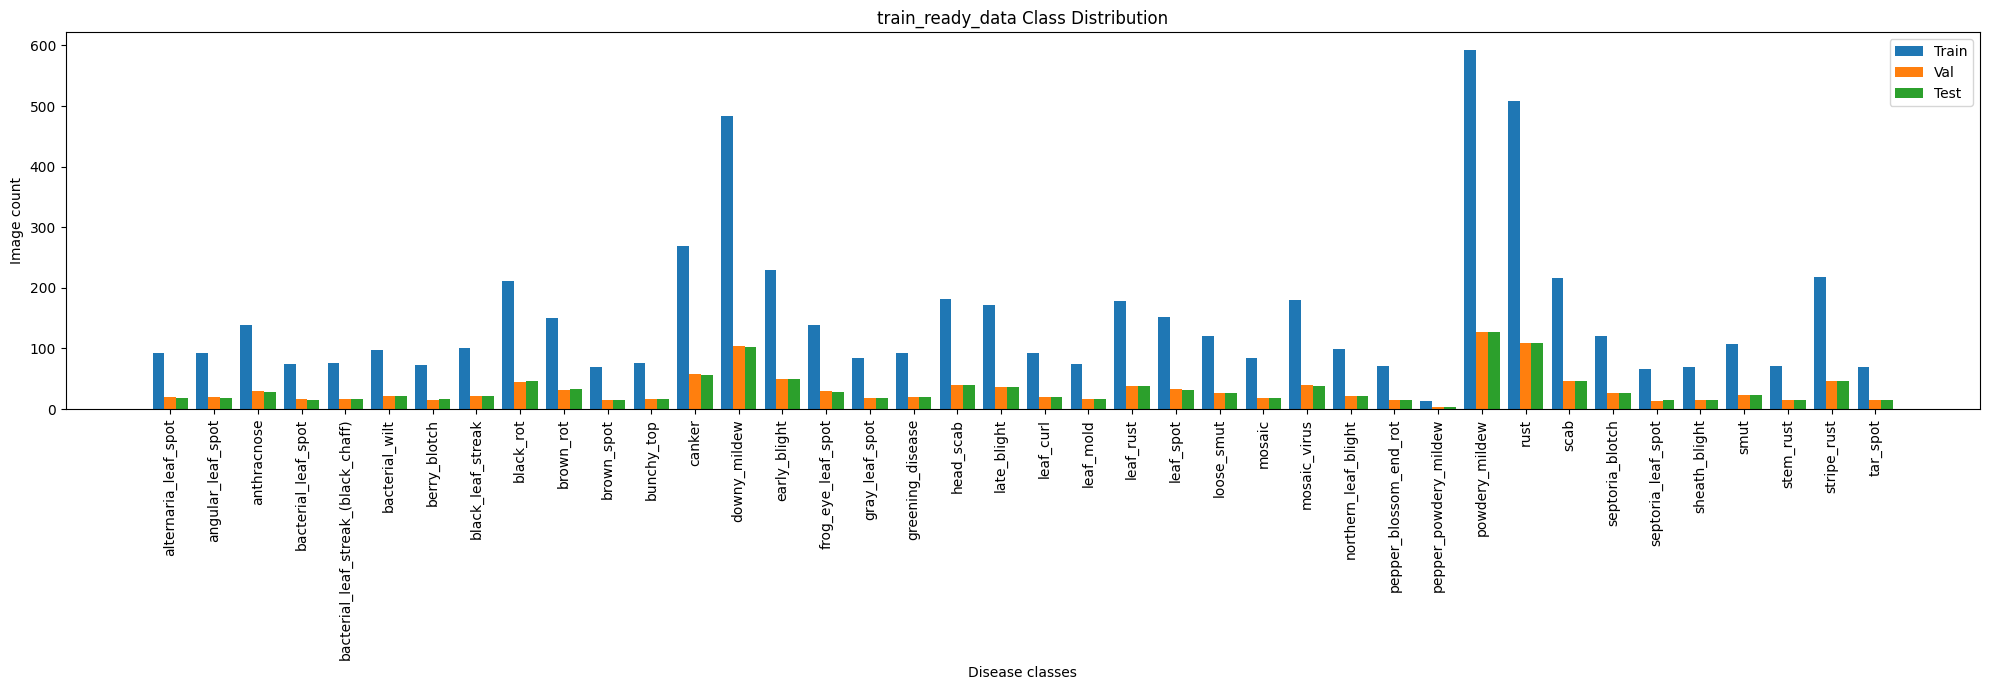


Report saved to: C:\Users\Sevak\Desktop\New folder\train_ready_data\preprocessing_report.json


In [10]:
def collect_unique_records(source_splits):
    class_records = defaultdict(list)
    hash_to_label = {}
    duplicate_total = 0
    cross_label_duplicates = 0

    for split_dir in source_splits:
        if not split_dir.exists():
            continue

        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue

            label = class_dir.name
            for img_path in sorted(class_dir.iterdir()):
                if not is_image_file(img_path):
                    continue

                h = file_md5(img_path)
                if h in hash_to_label:
                    duplicate_total += 1
                    if hash_to_label[h] != label:
                        cross_label_duplicates += 1
                    continue

                hash_to_label[h] = label
                class_records[label].append({'path': img_path, 'hash': h})

    print(f'Unique images collected: {sum(len(v) for v in class_records.values())}')
    print(f'Duplicates removed: {duplicate_total}')
    print(f'Cross-label duplicates skipped: {cross_label_duplicates}')

    return class_records

def build_train_ready_dataset(class_records, output_root, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    if output_root.exists():
        shutil.rmtree(output_root)

    for split in ['train', 'val', 'test']:
        (output_root / split).mkdir(parents=True, exist_ok=True)

    rng = random.Random(seed)
    split_class_counts = {'train': Counter(), 'val': Counter(), 'test': Counter()}
    small_classes = []

    for cls in sorted(class_records):
        records = class_records[cls][:]
        rng.shuffle(records)
        n = len(records)

        if n < 3:
            small_classes.append((cls, n))

        n_train, n_val, n_test = split_counts_for_class(
            n,
            train_ratio=train_ratio,
            val_ratio=val_ratio,
            test_ratio=test_ratio,
        )

        partitions = {
            'train': records[:n_train],
            'val': records[n_train:n_train + n_val],
            'test': records[n_train + n_val:n_train + n_val + n_test],
        }

        for split_name, items in partitions.items():
            dst_class = output_root / split_name / cls
            dst_class.mkdir(parents=True, exist_ok=True)
            for item in items:
                src = item['path']
                prefix = item['hash'][:10] + '__'
                copy_unique(src, dst_class, prefix=prefix)
                split_class_counts[split_name][cls] += 1

    if small_classes:
        print('Classes with fewer than 3 images (test may be empty):')
        for cls, n in small_classes:
            print(f'  {cls}: {n}')

    return split_class_counts

def build_hash_set(split_dir):
    hashes = set()
    for p in split_dir.rglob('*'):
        if is_image_file(p):
            hashes.add(file_md5(p))
    return hashes

class_records = collect_unique_records([RESIZED_ROOT / 'train', RESIZED_ROOT / 'val'])
_ = build_train_ready_dataset(
    class_records,
    READY_ROOT,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
)

ready_train_counts = summarize_split(READY_ROOT / 'train', 'READY TRAIN')
ready_val_counts = summarize_split(READY_ROOT / 'val', 'READY VAL')
ready_test_counts = summarize_split(READY_ROOT / 'test', 'READY TEST')

train_hashes = build_hash_set(READY_ROOT / 'train')
val_hashes = build_hash_set(READY_ROOT / 'val')
test_hashes = build_hash_set(READY_ROOT / 'test')

print('')
print('Leakage check (hash intersections):')
print(f'Train vs Val : {len(train_hashes & val_hashes)}')
print(f'Train vs Test: {len(train_hashes & test_hashes)}')
print(f'Val vs Test  : {len(val_hashes & test_hashes)}')

all_classes = sorted(set(ready_train_counts) | set(ready_val_counts) | set(ready_test_counts))
train_vals = [ready_train_counts.get(c, 0) for c in all_classes]
val_vals = [ready_val_counts.get(c, 0) for c in all_classes]
test_vals = [ready_test_counts.get(c, 0) for c in all_classes]

x = np.arange(len(all_classes))
width = 0.27

plt.figure(figsize=(20, 7))
plt.bar(x - width, train_vals, width, label='Train')
plt.bar(x, val_vals, width, label='Val')
plt.bar(x + width, test_vals, width, label='Test')
plt.xticks(x, all_classes, rotation=90)
plt.title('train_ready_data Class Distribution')
plt.xlabel('Disease classes')
plt.ylabel('Image count')
plt.legend()
plt.tight_layout()
plt.show()

report = {
    'seed': SEED,
    'target_size': TARGET_SIZE,
    'min_val_samples_per_class': MIN_VAL_SAMPLES_PER_CLASS,
    'split_ratios': {'train': TRAIN_RATIO, 'val': VAL_RATIO, 'test': TEST_RATIO},
    'clean': {
        'train_classes': len(clean_train_counts),
        'val_classes': len(clean_val_counts),
        'train_images': int(sum(clean_train_counts.values())),
        'val_images': int(sum(clean_val_counts.values())),
    },
    'resized': {
        'train_classes': len(resized_train_counts),
        'val_classes': len(resized_val_counts),
        'train_images': int(sum(resized_train_counts.values())),
        'val_images': int(sum(resized_val_counts.values())),
    },
    'train_ready_data': {
        'train_classes': len(ready_train_counts),
        'val_classes': len(ready_val_counts),
        'test_classes': len(ready_test_counts),
        'train_images': int(sum(ready_train_counts.values())),
        'val_images': int(sum(ready_val_counts.values())),
        'test_images': int(sum(ready_test_counts.values())),
        'leakage': {
            'train_val': int(len(train_hashes & val_hashes)),
            'train_test': int(len(train_hashes & test_hashes)),
            'val_test': int(len(val_hashes & test_hashes)),
        },
    },
}

report_path = READY_ROOT / 'preprocessing_report.json'
with report_path.open('w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)

print('')
print(f'Report saved to: {report_path.resolve()}')

In [11]:
import os
import hashlib

def get_image_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def collect_hashes(folder):
    hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                full_path = os.path.join(root, file)
                try:
                    file_hash = get_image_hash(full_path)
                    hashes[file_hash] = full_path
                except:
                    pass
    return hashes

train_dir = "train_ready_data/train"
val_dir   = "train_ready_data/val"
test_dir  = "train_ready_data/test"

train_hashes = collect_hashes(train_dir)
val_hashes   = collect_hashes(val_dir)
test_hashes  = collect_hashes(test_dir)

# intersections
train_val = set(train_hashes.keys()) & set(val_hashes.keys())
train_test = set(train_hashes.keys()) & set(test_hashes.keys())
val_test = set(val_hashes.keys()) & set(test_hashes.keys())

print("Train ∩ Val:", len(train_val))
print("Train ∩ Test:", len(train_test))
print("Val ∩ Test:", len(val_test))

# եթե ուզում ես տեսնել կոնկրետ ֆայլերը
if len(train_val) > 0:
    print("\nExample leakage (Train-Val):")
    for h in list(train_val)[:5]:
        print(train_hashes[h], " <-> ", val_hashes[h])

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0
